# Credit-G Decision Tree

In [1]:
import pandas as pd
from scipy.io import arff
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    f1_score,
 )

In [ ]:
# creating the dataset using onehot encoding

df = pd.DataFrame(data)

for col in df.columns:
    if df[col].dtype == 'object':
        try:
            df[col] = df[col].str.decode('utf-8')
        except Exception:
            pass

categorical_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

target_col = None
for candidate in ['class', 'target', 'label', 'y']:
    if candidate in df.columns:
        target_col = candidate
        break

ohe_cols = [c for c in categorical_cols if c != target_col]
df_ohe = pd.get_dummies(df, columns=ohe_cols, drop_first=False, dtype=int)

if target_col is not None:
    X_ohe = df_ohe.drop(columns=[target_col])
    y = df_ohe[target_col]
else:
    X_ohe = df_ohe

print(f"Raw df shape: {df.shape}")
print(f"One-hot df_ohe shape: {df_ohe.shape}")
print(f"One-hot features shape (X_ohe): {X_ohe.shape}")
if target_col is not None:
    print(f"Target column: {target_col} (dtype={y.dtype})")

Raw df shape: (1000, 21)
One-hot df_ohe shape: (1000, 62)
One-hot features shape (X_ohe): (1000, 61)
Target column: class (dtype=object)


In [ ]:
X_encoded = X_ohe.copy()
y_encoded = y.copy() 

class_names = sorted(pd.Series(y_encoded).unique().tolist())

X_encoded.head()

,duration,credit_amount,installment_commitment,residence_since,age,existing_credits,num_dependents,checking_status_0<=X<200,checking_status_<0,checking_status_>=200,...,housing_own,housing_rent,job_high qualif/self emp/mgmt,job_skilled,job_unemp/unskilled non res,job_unskilled resident,own_telephone_none,own_telephone_yes,foreign_worker_no,foreign_worker_yes
0,6.0,1169.0,4.0,4.0,67.0,2.0,1.0,0,1,0,...,1,0,0,1,0,0,0,1,0,1
1,48.0,5951.0,2.0,2.0,22.0,1.0,1.0,1,0,0,...,1,0,0,1,0,0,1,0,0,1
2,12.0,2096.0,2.0,3.0,49.0,1.0,2.0,0,0,0,...,1,0,0,0,0,1,1,0,0,1
3,42.0,7882.0,2.0,4.0,45.0,1.0,2.0,0,1,0,...,0,0,0,1,0,0,1,0,0,1
4,24.0,4870.0,3.0,4.0,53.0,2.0,2.0,0,1,0,...,0,0,0,1,0,0,1,0,0,1


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y_encoded,
    test_size=0.3,
    random_state=42,
    stratify=y_encoded,
 )

## Depth-Limited Tree (max_depth=5)

In [14]:
clf_5 = DecisionTreeClassifier(max_depth=5, random_state=42)
clf_5.fit(X_train, y_train)
y_pred_5 = clf_5.predict(X_test)

print(f"Train accuracy: {accuracy_score(y_train, clf_5.predict(X_train)):.4f}")
print(f"Test accuracy:  {accuracy_score(y_test, y_pred_5):.4f}")

Train accuracy: 0.7929
Test accuracy:  0.6967


In [ ]:
if len(class_names) == 2:
    pos_label = 'good' if 'good' in class_names else class_names[1]
    print(f"Positive class (pos_label): {pos_label}")
    print(f"Precision: {precision_score(y_test, y_pred_5, pos_label=pos_label, zero_division=0):.4f}")
    print(f"Recall:    {recall_score(y_test, y_pred_5, pos_label=pos_label, zero_division=0):.4f}")
    print(f"F1:        {f1_score(y_test, y_pred_5, pos_label=pos_label, zero_division=0):.4f}")
else:
    print(f"Precision (weighted): {precision_score(y_test, y_pred_5, average='weighted', zero_division=0):.4f}")
    print(f"Recall (weighted):    {recall_score(y_test, y_pred_5, average='weighted', zero_division=0):.4f}")
    print(f"F1 (weighted):        {f1_score(y_test, y_pred_5, average='weighted', zero_division=0):.4f}")

print()
print(classification_report(y_test, y_pred_5, labels=class_names))

Positive class (pos_label): good
Precision: 0.7532
Recall:    0.8429
F1:        0.7955

              precision    recall  f1-score   support

         bad       0.49      0.36      0.41        90
        good       0.75      0.84      0.80       210

    accuracy                           0.70       300
   macro avg       0.62      0.60      0.60       300
weighted avg       0.67      0.70      0.68       300



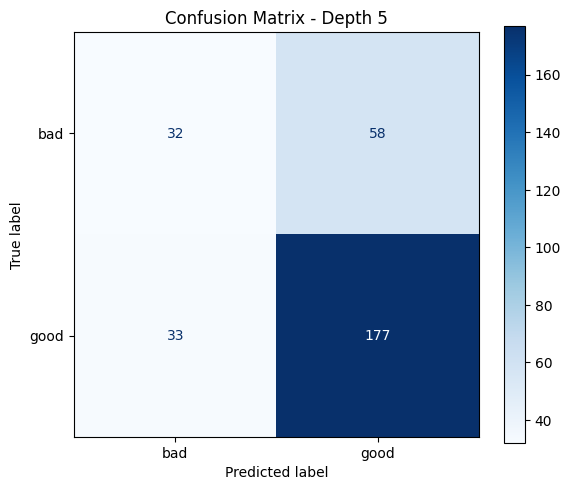

In [8]:
cm_5 = confusion_matrix(y_test, y_pred_5, labels=class_names)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_5, display_labels=class_names)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title('Confusion Matrix - Depth 5')
plt.tight_layout()
plt.show()

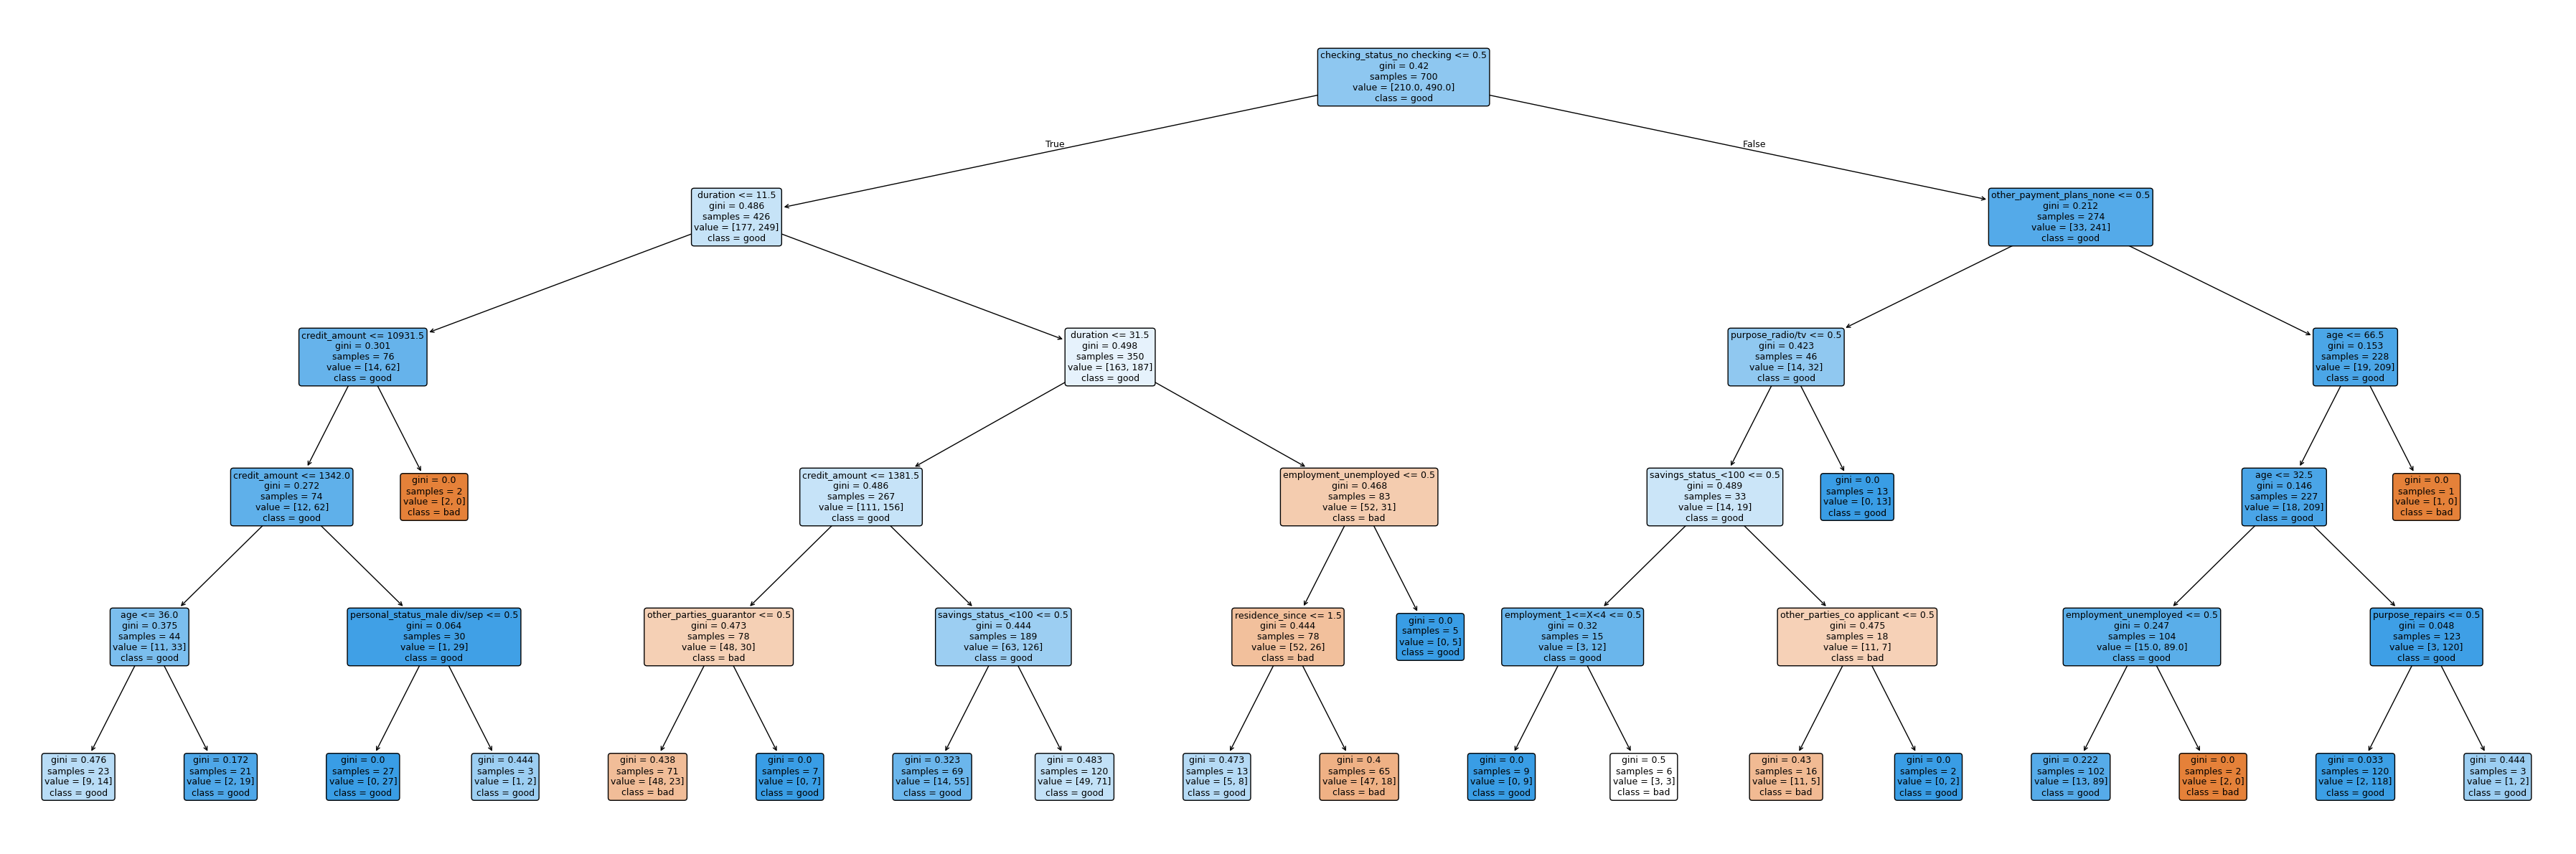

In [9]:
fig, ax = plt.subplots(figsize=(36, 12))
plot_tree(
    clf_5,
    feature_names=X_encoded.columns.tolist(),
    class_names=class_names,
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax,
 )
plt.tight_layout()
plt.savefig('decision_tree_depth5.png', dpi=150, bbox_inches='tight')
plt.show()

## Depth-Limited Tree (max_depth=3)

In [15]:
clf_d3 = DecisionTreeClassifier(max_depth=3, random_state=42)
clf_d3.fit(X_train, y_train)
y_pred_d3 = clf_d3.predict(X_test)

print(f"Train accuracy: {accuracy_score(y_train, clf_d3.predict(X_train)):.4f}")
print(f"Test accuracy:  {accuracy_score(y_test, y_pred_d3):.4f}")

Train accuracy: 0.7343
Test accuracy:  0.7133


In [ ]:
if len(class_names) == 2:
    pos_label = 'good' if 'good' in class_names else class_names[1]
    print(f"Positive class (pos_label): {pos_label}")
    print(f"Precision: {precision_score(y_test, y_pred_d3, pos_label=pos_label, zero_division=0):.4f}")
    print(f"Recall:    {recall_score(y_test, y_pred_d3, pos_label=pos_label, zero_division=0):.4f}")
    print(f"F1:        {f1_score(y_test, y_pred_d3, pos_label=pos_label, zero_division=0):.4f}")
else:
    print(f"Precision (weighted): {precision_score(y_test, y_pred_d3, average='weighted', zero_division=0):.4f}")
    print(f"Recall (weighted):    {recall_score(y_test, y_pred_d3, average='weighted', zero_division=0):.4f}")
    print(f"F1 (weighted):        {f1_score(y_test, y_pred_d3, average='weighted', zero_division=0):.4f}")

print()
print(classification_report(y_test, y_pred_d3, labels=class_names))

Positive class (pos_label): good
Precision: 0.7331
Recall:    0.9286
F1:        0.8193

              precision    recall  f1-score   support

         bad       0.56      0.21      0.31        90
        good       0.73      0.93      0.82       210

    accuracy                           0.71       300
   macro avg       0.65      0.57      0.56       300
weighted avg       0.68      0.71      0.67       300



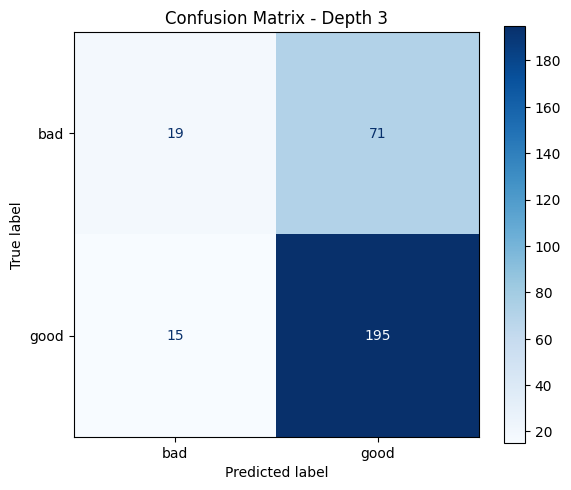

In [12]:
cm_d3 = confusion_matrix(y_test, y_pred_d3, labels=class_names)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_d3, display_labels=class_names)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title('Confusion Matrix - Depth 3')
plt.tight_layout()
plt.show()

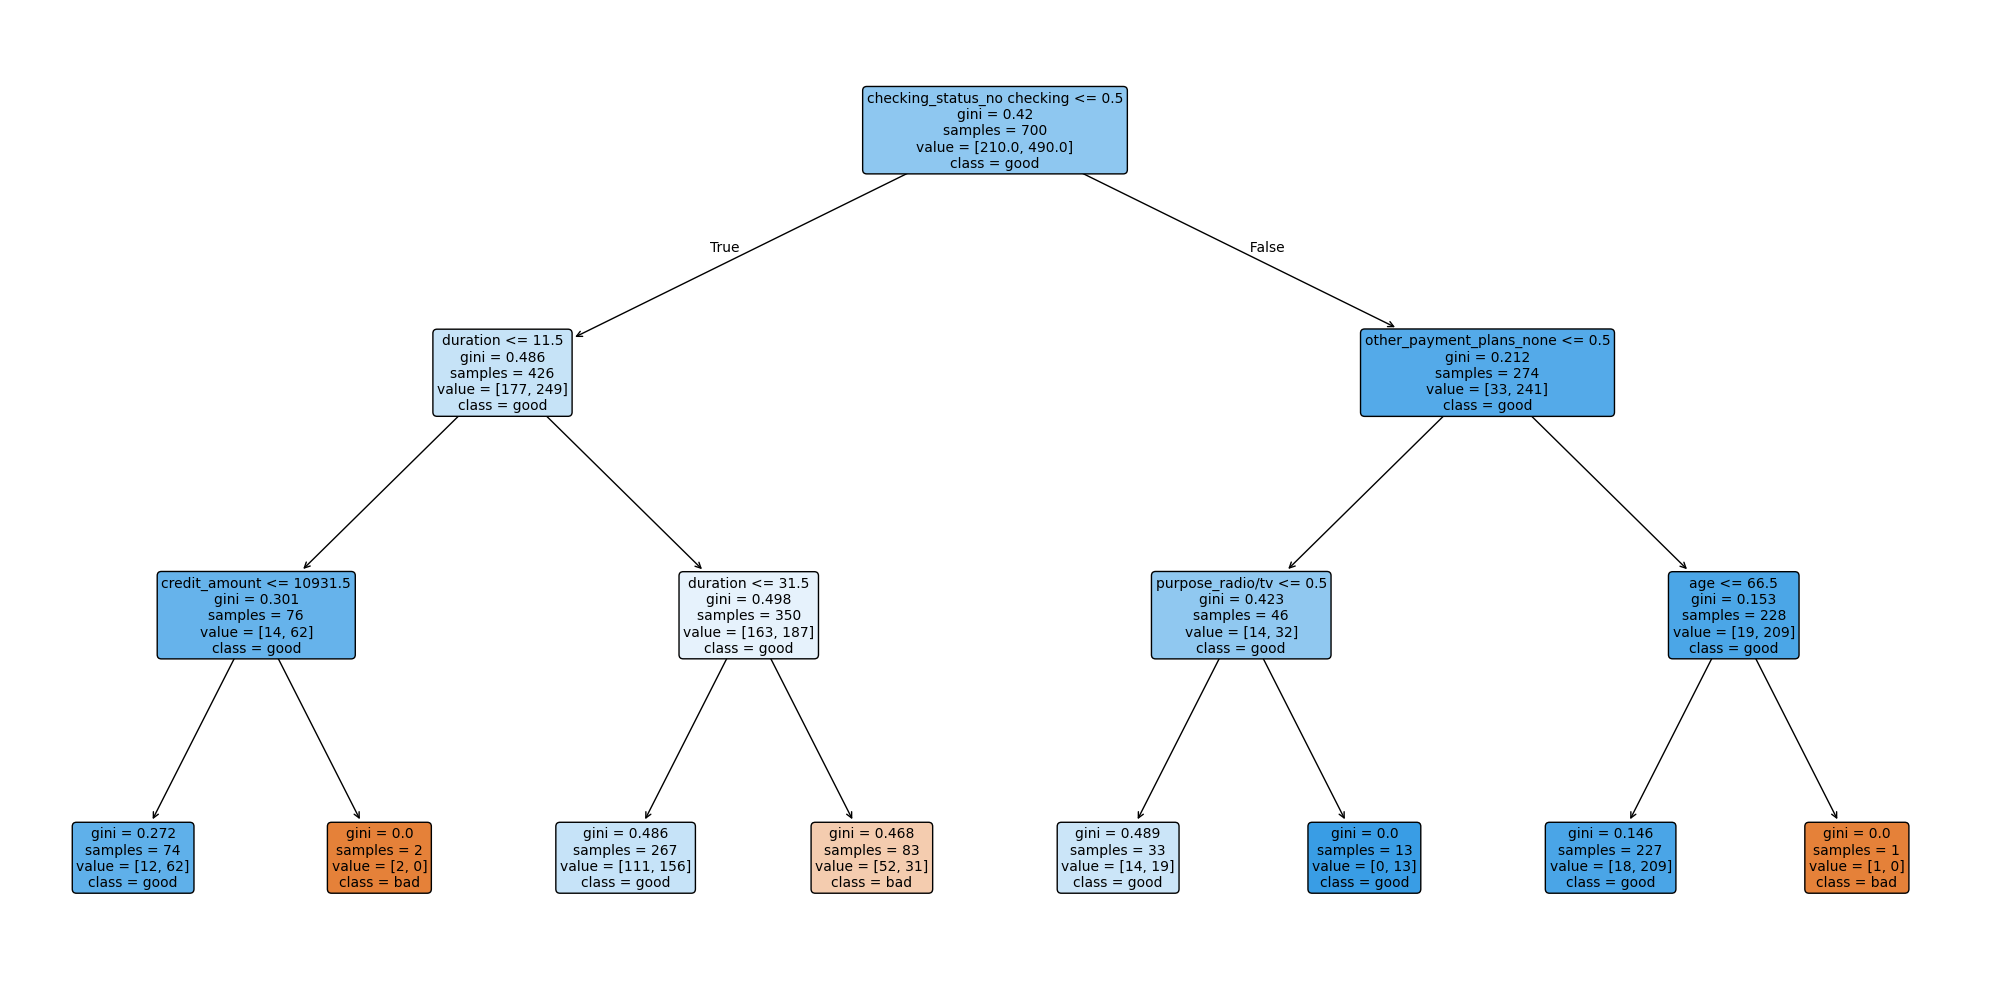

In [13]:
fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(
    clf_d3,
    feature_names=X_encoded.columns.tolist(),
    class_names=class_names,
    filled=True,
    rounded=True,
    fontsize=10,
    ax=ax,
 )
plt.tight_layout()
plt.savefig('decision_tree_depth3.png', dpi=150, bbox_inches='tight')
plt.show()